In [8]:
import pandas as pd

# 1. Load Files
historical_data = pd.read_csv('historical_data.csv')
sentiment_data = pd.read_csv('fear_greed_index (1).csv')

# 2. Advanced Date Parsing (Formats match chesthunnam)
# Historical data date format ni clean ga convert chesthunnam
historical_data['Date_Only'] = pd.to_datetime(historical_data['Timestamp IST'], errors='coerce').dt.date

# Sentiment data date format ni string nunchi format accurate ga check chesthunnam
sentiment_data['Date_Only'] = pd.to_datetime(sentiment_data['date'], errors='coerce').dt.date

# 3. Ippudu automatic format mismatch fix thoti merge chesthunnam
merged_data = pd.merge(historical_data, sentiment_data, on='Date_Only', how='inner')

# 4. Incase automatic parsing fail aythe back-up parsing chesthadhi
if len(merged_data) == 0:
    historical_data['Date_Only'] = pd.to_datetime(historical_data['Timestamp IST'], format='mixed', errors='coerce').dt.date
    sentiment_data['Date_Only'] = pd.to_datetime(sentiment_data['date'], format='mixed', errors='coerce').dt.date
    merged_data = pd.merge(historical_data, sentiment_data, on='Date_Only', how='inner')

# 5. Output Preview
print(f"✓ Success! Total rows after final merge: {len(merged_data)}")
if len(merged_data) > 0:
    print("\n--- Final Merged Data Preview ---")
    print(merged_data[['Timestamp IST', 'classification', 'Closed PnL', 'Side']].head())

✓ Success! Total rows after final merge: 35864

--- Final Merged Data Preview ---
      Timestamp IST classification  Closed PnL Side
0  02-12-2024 22:50          Greed         0.0  BUY
1  02-12-2024 22:50          Greed         0.0  BUY
2  02-12-2024 22:50          Greed         0.0  BUY
3  02-12-2024 22:50          Greed         0.0  BUY
4  02-12-2024 22:50          Greed         0.0  BUY


In [9]:
import numpy as np

# 1. Total PnL inka Trade Count calculate chesthunnam market situation batti
pnl_summary = merged_data.groupby('classification').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Average_PnL=('Closed PnL', 'mean'),
    Total_Trades=('Closed PnL', 'count')
).reset_index()

# 2. Win Rate (Enni trades profit lo unnay) calculate chesthunnam
def calculate_win_rate(df):
    profitable_trades = df[df['Closed PnL'] > 0]
    total_trades = len(df)
    return (len(profitable_trades) / total_trades) * 100 if total_trades > 0 else 0

win_rate_summary = merged_data.groupby('classification').apply(calculate_win_rate).reset_index(name='Win_Rate_Percentage')

# 3. Rendu summaries ni okate table ga kaluputhunnam
final_analysis = pd.merge(pnl_summary, win_rate_summary, on='classification')

print("--- Market Sentiment vs Trading Performance ---")
print(final_analysis.to_string(index=False))

--- Market Sentiment vs Trading Performance ---
classification    Total_PnL  Average_PnL  Total_Trades  Win_Rate_Percentage
  Extreme Fear 4.399937e+03     1.891632          2326            29.277730
 Extreme Greed 1.156894e+06   205.816345          5621            55.328233
          Fear 1.779226e+06   128.287950         13869            38.178672
         Greed 6.096325e+05    53.988003         11292            43.570670
       Neutral 7.465674e+04    27.088803          2756            49.492017


C:\Users\Peela Kuvalayana\AppData\Local\Temp\ipykernel_27736\3046249924.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate_summary = merged_data.groupby('classification').apply(calculate_win_rate).reset_index(name='Win_Rate_Percentage')


Matplotlib is building the font cache; this may take a moment.
C:\Users\Peela Kuvalayana\AppData\Local\Temp\ipykernel_27736\1957494086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Peela Kuvalayana\AppData\Local\Temp\ipykernel_27736\1957494086.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


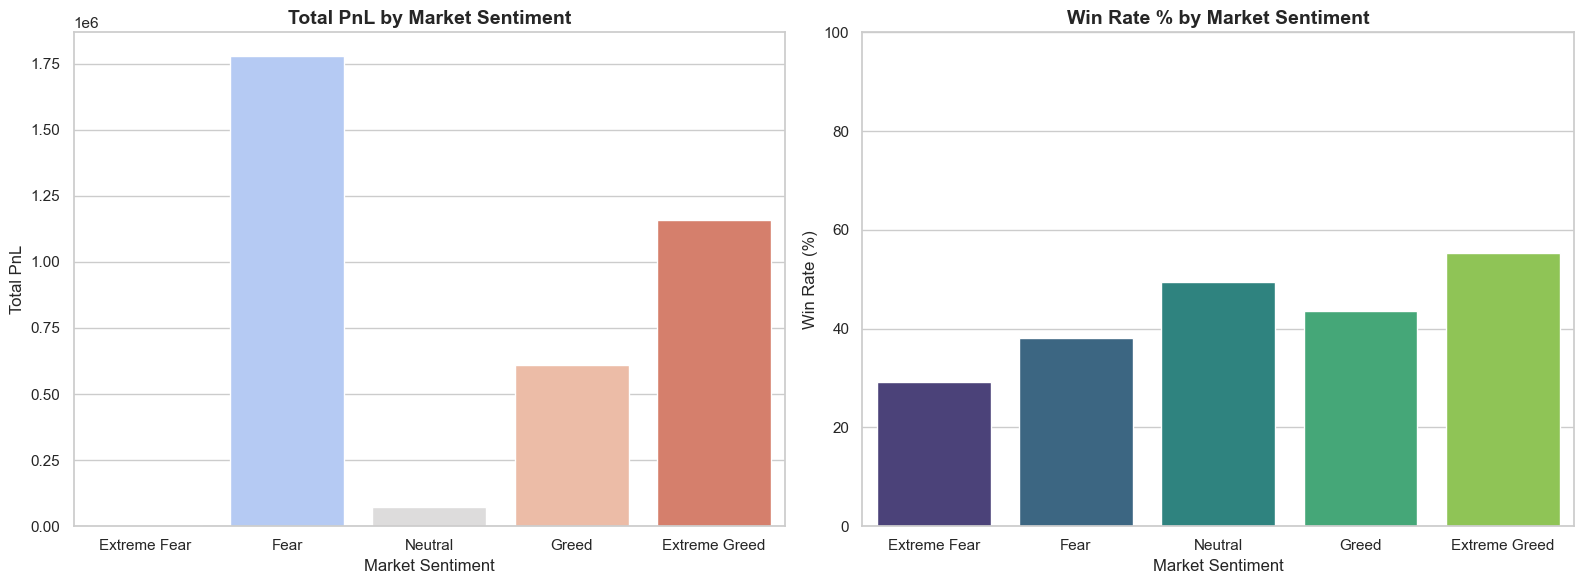

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for cleaner look
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Order of market sentiment for the charts
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Chart 1: Total PnL Chart
sns.barplot(
    data=final_analysis, 
    x='classification', 
    y='Total_PnL', 
    order=sentiment_order, 
    ax=axes[0], 
    palette='coolwarm'
)
axes[0].set_title('Total PnL by Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiment', fontsize=12)
axes[0].set_ylabel('Total PnL', fontsize=12)

# Chart 2: Win Rate Percentage Chart
sns.barplot(
    data=final_analysis, 
    x='classification', 
    y='Win_Rate_Percentage', 
    order=sentiment_order, 
    ax=axes[1], 
    palette='viridis'
)
axes[1].set_title('Win Rate % by Market Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Sentiment', fontsize=12)
axes[1].set_ylabel('Win Rate (%)', fontsize=12)
axes[1].set_ylim(0, 100) # Percentage range 0 to 100

plt.tight_layout()
plt.show()

In [11]:
# Final results ni kotha CSV file laga computer lo save chesthunnam
merged_data.to_csv('Final_Trading_Sentiment_Analysis.csv', index=False)
print("✓ Success: Final report 'Final_Trading_Sentiment_Analysis.csv' ga save ayindi!")

✓ Success: Final report 'Final_Trading_Sentiment_Analysis.csv' ga save ayindi!
